In [1]:
import pandas as pd

# Load Excel file
df = pd.read_excel("dataset.xlsx")

# Save as CSV
df.to_csv("dataset.csv", index=False)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('dataset.csv', encoding='latin-1')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nFirst few rows:")
df.head()

Shape: (1514, 6)

Columns: ['Repository Link', 'File name', 'Function name', 'code_section', 'Approximate Number of Lines', 'Long Method']

Data Types:
 Repository Link                object
File name                      object
Function name                  object
code_section                   object
Approximate Number of Lines     int64
Long Method                    object
dtype: object

First few rows:


,Repository Link,File name,Function name,code_section,Approximate Number of Lines,Long Method
0,https://github.com/public-apis/public-apis.git,scripts/tests/test_validate_format.py,test_error_message_return_and_return_type,def test_error_message_return_and_return_type(...,18,No
1,https://github.com/public-apis/public-apis.git,scripts/tests/test_validate_format.py,test_if_get_categories_content_return_correct_...,def test_if_get_categories_content_return_corr...,23,No
2,https://github.com/public-apis/public-apis.git,scripts/tests/test_validate_format.py,test_if_check_alphabetical_order_return_correc...,def test_if_check_alphabetical_order_return_co...,40,Yes
3,https://github.com/public-apis/public-apis.git,scripts/tests/test_validate_format.py,test_check_title_with_correct_title,def test_check_title_with_correct_title(self):...,6,No
4,https://github.com/public-apis/public-apis.git,scripts/tests/test_validate_format.py,test_check_title_with_markdown_syntax_incorrect,def test_check_title_with_markdown_syntax_inco...,8,No


In [2]:
# Keep only relevant features
df = df[['code_section', 'Approximate Number of Lines', 'Long Method']].copy()
df.columns = ['code_section', 'num_lines', 'long_method']

print("Missing values:\n", df.isnull().sum())
print("\nTarget distribution:\n", df['long_method'].value_counts())
print("\nBasic stats:\n", df.describe())

Missing values:
 code_section    0
num_lines       0
long_method     0
dtype: int64

Target distribution:
 long_method
No     841
Yes    673
Name: count, dtype: int64

Basic stats:
          num_lines
count  1514.000000
mean     36.445839
std      52.847747
min       1.000000
25%       7.000000
50%      24.000000
75%      47.000000
max     866.000000


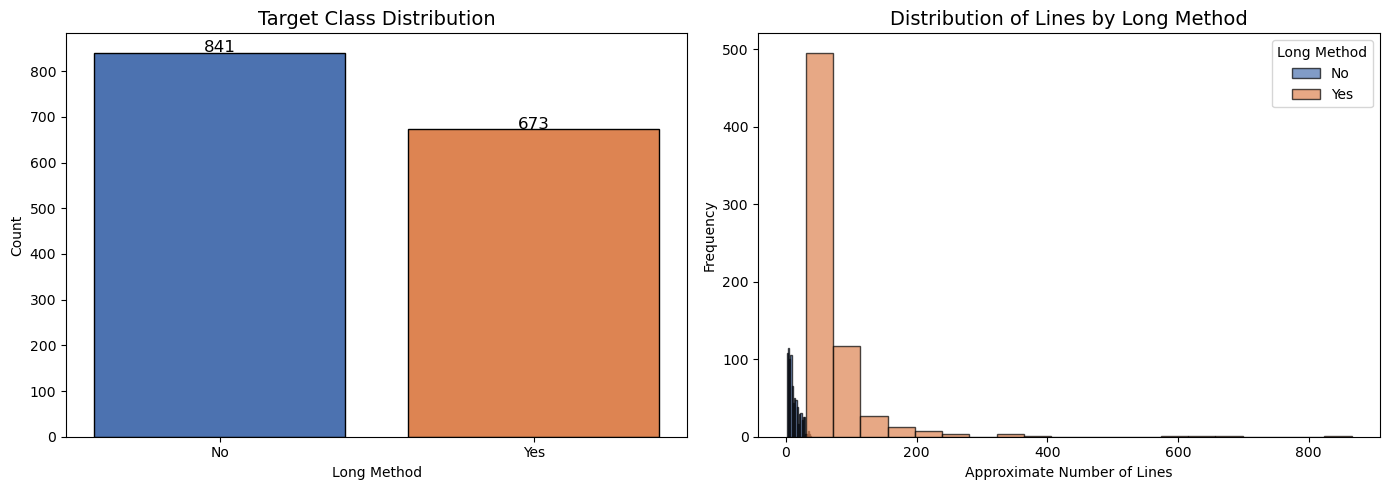

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Target class distribution
counts = df['long_method'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#4C72B0', '#DD8452'], edgecolor='black')
axes[0].set_title('Target Class Distribution', fontsize=14)
axes[0].set_xlabel('Long Method')
axes[0].set_ylabel('Count')
for i, (label, val) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, val + 1, str(val), ha='center', fontsize=12)

# 2. Distribution of Approximate Number of Lines
for label, color in zip(['No', 'Yes'], ['#4C72B0', '#DD8452']):
    subset = df[df['long_method'] == label]['num_lines']
    axes[1].hist(subset, bins=20, alpha=0.7, label=label, color=color, edgecolor='black')
axes[1].set_title('Distribution of Lines by Long Method', fontsize=14)
axes[1].set_xlabel('Approximate Number of Lines')
axes[1].set_ylabel('Frequency')
axes[1].legend(title='Long Method')

plt.tight_layout()
plt.savefig('viz_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

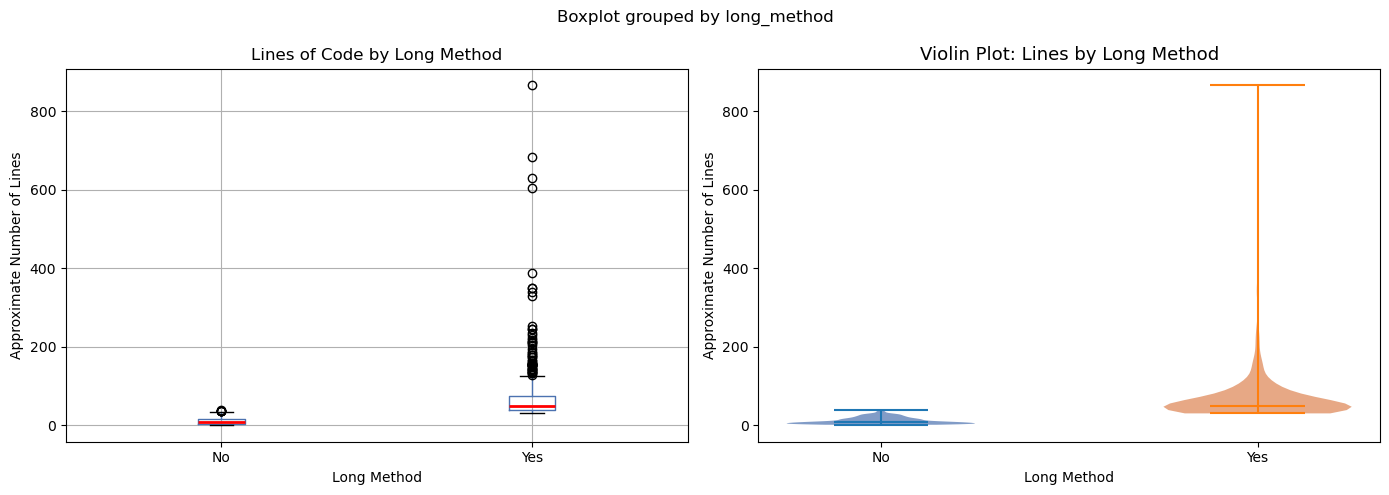

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot: num_lines by long_method
df.boxplot(column='num_lines', by='long_method', ax=axes[0],
           boxprops=dict(color='#4C72B0'),
           medianprops=dict(color='red', linewidth=2),
           whiskerprops=dict(color='#4C72B0'))
axes[0].set_title('Lines of Code by Long Method', fontsize=13)
axes[0].set_xlabel('Long Method')
axes[0].set_ylabel('Approximate Number of Lines')
plt.sca(axes[0])
plt.title('Lines of Code by Long Method')

# Violin plot
import matplotlib.patches as mpatches
for i, (label, color) in enumerate(zip(['No', 'Yes'], ['#4C72B0', '#DD8452'])):
    subset = df[df['long_method'] == label]['num_lines']
    parts = axes[1].violinplot(subset, positions=[i], showmedians=True)
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No', 'Yes'])
axes[1].set_title('Violin Plot: Lines by Long Method', fontsize=13)
axes[1].set_xlabel('Long Method')
axes[1].set_ylabel('Approximate Number of Lines')

plt.tight_layout()
plt.savefig('viz_boxplot_violin.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Feature Engineering from code_section
def extract_code_features(code):
    code = str(code)
    lines = code.split('\n')
    return pd.Series({
        'code_char_count': len(code),
        'code_line_count': len(lines),
        'code_word_count': len(code.split()),
        'code_avg_line_len': np.mean([len(l) for l in lines]) if lines else 0,
        'code_max_line_len': max([len(l) for l in lines]) if lines else 0,
        'code_indent_depth': max([len(l) - len(l.lstrip()) for l in lines if l.strip()] or [0]),
        'code_has_loop': int(any(kw in code for kw in ['for ', 'while '])),
        'code_has_conditional': int(any(kw in code for kw in ['if ', 'elif ', 'else:'])),
        'code_has_return': int('return' in code),
        'code_has_try': int('try:' in code or 'except' in code),
        'code_num_returns': code.count('return'),
        'code_num_ifs': code.count('if '),
        'code_num_loops': code.count('for ') + code.count('while '),
        'code_comment_lines': sum(1 for l in lines if l.strip().startswith('#')),
    })

features_df = df['code_section'].apply(extract_code_features)
df_features = pd.concat([features_df, df[['num_lines', 'long_method']]], axis=1)

print("Feature matrix shape:", df_features.shape)
df_features.head()

Feature matrix shape: (1514, 16)


,code_char_count,code_line_count,code_word_count,code_avg_line_len,code_max_line_len,code_indent_depth,code_has_loop,code_has_conditional,code_has_return,code_has_try,code_num_returns,code_num_ifs,code_num_loops,code_comment_lines,num_lines,long_method
0,938.0,22.0,73.0,41.681818,73.0,8.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,18,No
1,1128.0,28.0,112.0,39.321429,84.0,16.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,23,No
2,1857.0,48.0,194.0,37.708333,73.0,16.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,40,Yes
3,267.0,8.0,15.0,32.500000,46.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6,No
4,406.0,12.0,26.0,32.916667,74.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8,No


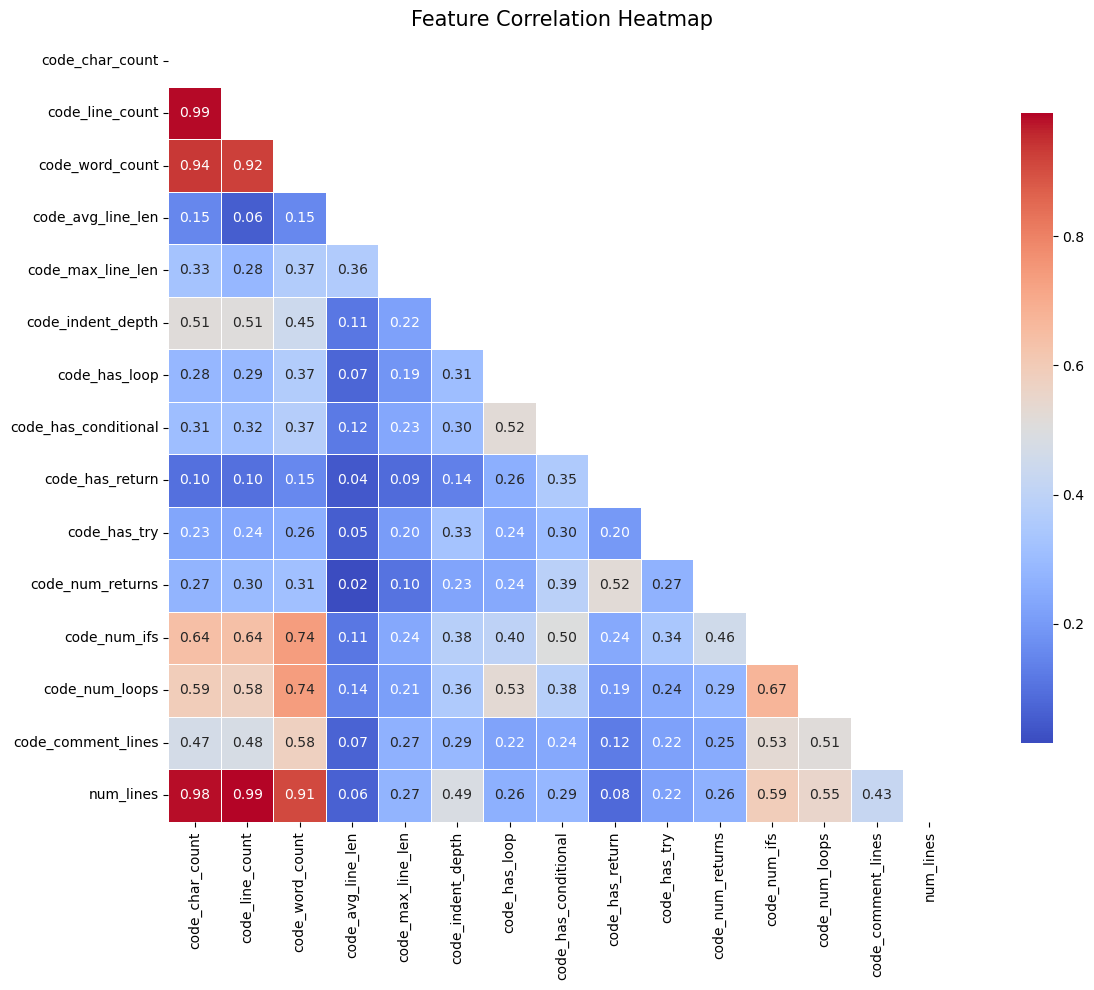

In [6]:
# Correlation heatmap of engineered features
plt.figure(figsize=(14, 10))
corr = df_features.drop(columns=['long_method']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=15)
plt.tight_layout()
plt.savefig('viz_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Prepare X and y
X = df_features.drop(columns=['long_method'])
le = LabelEncoder()
y = le.fit_transform(df_features['long_method'])  # Yes=1, No=0
print("Classes:", le.classes_)
print("Class counts:", np.bincount(y))

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {len(X_train)} | Test size: {len(X_test)}")

Classes: ['No' 'Yes']
Class counts: [841 673]

Train size: 1211 | Test size: 303


In [8]:
# Define models
models = {
    'Logistic Regression': Pipeline([('scaler', StandardScaler()),
                                      ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    'Decision Tree':        Pipeline([('clf', DecisionTreeClassifier(random_state=42))]),
    'Random Forest':        Pipeline([('clf', RandomForestClassifier(n_estimators=100, random_state=42))]),
    'Gradient Boosting':    Pipeline([('clf', GradientBoostingClassifier(n_estimators=100, random_state=42))]),
    'SVM':                  Pipeline([('scaler', StandardScaler()),
                                      ('clf', SVC(probability=True, random_state=42))]),
    'KNN':                  Pipeline([('scaler', StandardScaler()),
                                      ('clf', KNeighborsClassifier())]),
}

# Cross-validation comparison
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1')
    results[name] = scores
    print(f"{name:25s}  F1: {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression        F1: 0.9610 ± 0.0138
Decision Tree              F1: 0.9751 ± 0.0047
Random Forest              F1: 0.9817 ± 0.0070
Gradient Boosting          F1: 0.9798 ± 0.0090
SVM                        F1: 0.9525 ± 0.0062
KNN                        F1: 0.9143 ± 0.0053


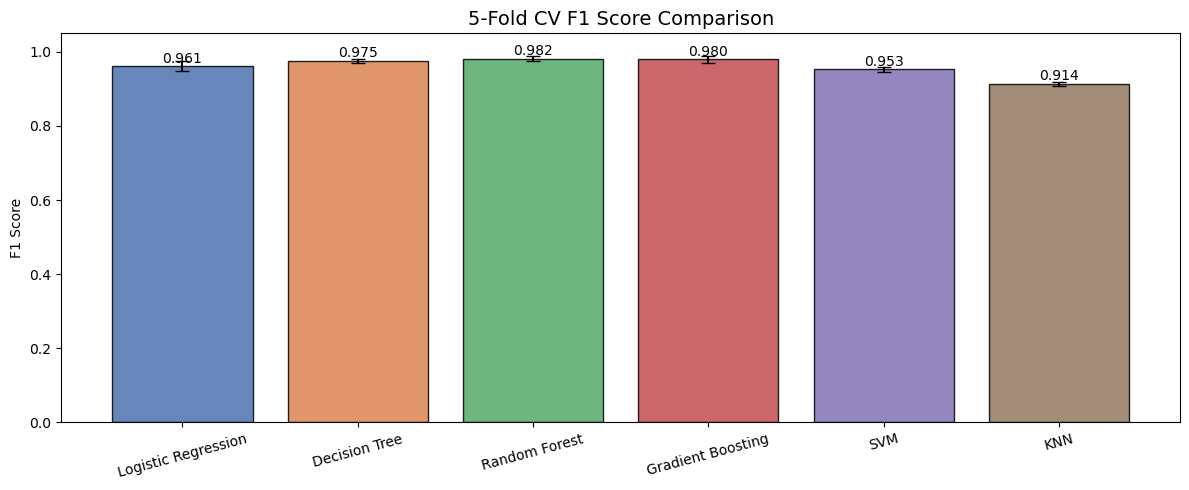


✅ Best Model: Random Forest (CV F1 = 0.9817)


In [9]:
# Model comparison bar plot
fig, ax = plt.subplots(figsize=(12, 5))
names = list(results.keys())
means = [results[n].mean() for n in names]
stds  = [results[n].std()  for n in names]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']
bars = ax.bar(names, means, yerr=stds, capsize=5, color=colors, edgecolor='black', alpha=0.85)
ax.set_title('5-Fold CV F1 Score Comparison', fontsize=14)
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=15)
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{mean:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('viz_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_model_name = max(results, key=lambda k: results[k].mean())
print(f"\n✅ Best Model: {best_model_name} (CV F1 = {results[best_model_name].mean():.4f})")

In [10]:
# Train best model on full training set and evaluate on test set
best_model = models[best_model_name]
best_model.fit(X_train, y_train)
y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(f"=== Best Model: {best_model_name} ===\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

=== Best Model: Random Forest ===

              precision    recall  f1-score   support

          No       0.99      0.99      0.99       168
         Yes       0.99      0.99      0.99       135

    accuracy                           0.99       303
   macro avg       0.99      0.99      0.99       303
weighted avg       0.99      0.99      0.99       303

ROC-AUC: 0.9993


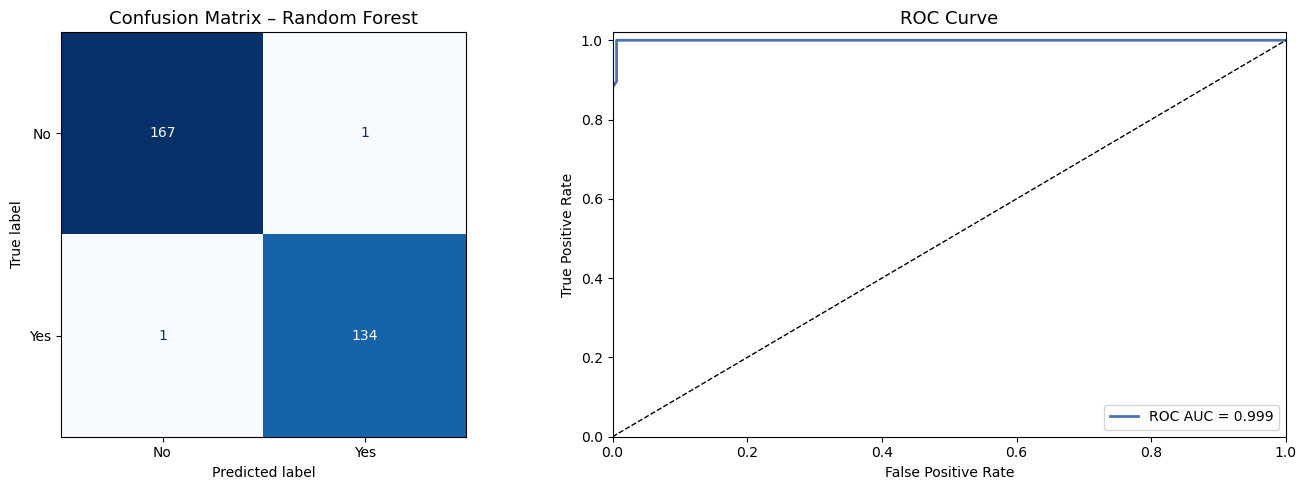

In [11]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion Matrix – {best_model_name}', fontsize=13)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_val = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#4C72B0', lw=2, label=f'ROC AUC = {auc_val:.3f}')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1.02])
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('viz_confusion_roc.png', dpi=150, bbox_inches='tight')
plt.show()

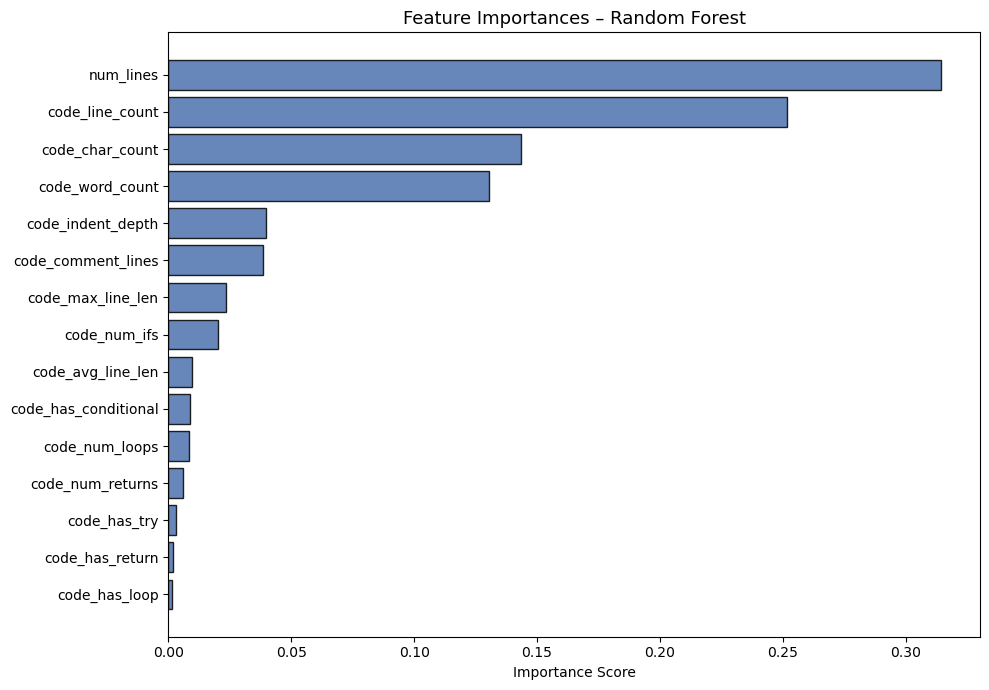

In [12]:
# Feature Importance (from tree-based best model, else use permutation importance)
from sklearn.inspection import permutation_importance

if hasattr(best_model[-1], 'feature_importances_'):
    importances = best_model[-1].feature_importances_
    feat_names = X.columns.tolist()
else:
    r = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42)
    importances = r.importances_mean
    feat_names = X.columns.tolist()

sorted_idx = np.argsort(importances)
plt.figure(figsize=(10, 7))
plt.barh([feat_names[i] for i in sorted_idx], importances[sorted_idx],
         color='#4C72B0', edgecolor='black', alpha=0.85)
plt.xlabel('Importance Score')
plt.title(f'Feature Importances – {best_model_name}', fontsize=13)
plt.tight_layout()
plt.savefig('viz_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

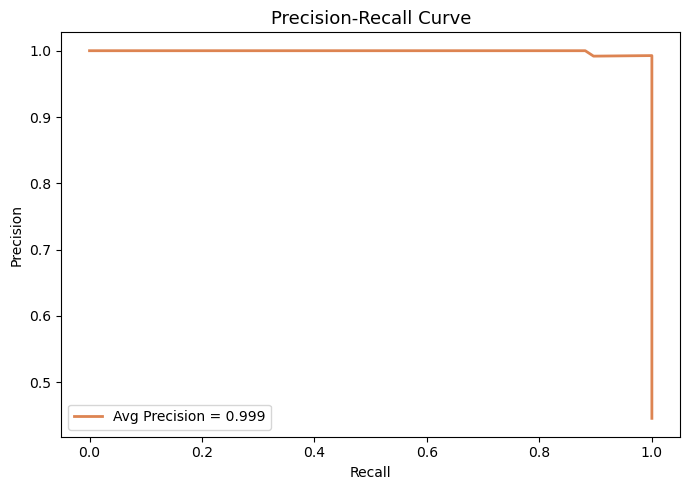

In [13]:
# Precision-Recall Curve
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, color='#DD8452', lw=2, label=f'Avg Precision = {ap:.3f}')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curve', fontsize=13)
plt.legend(); plt.tight_layout()
plt.savefig('viz_pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# All models on test set – summary table
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

summary_rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    yp = model.predict(X_test)
    yprob = model.predict_proba(X_test)[:, 1]
    summary_rows.append({
        'Model': name,
        'Accuracy':  round(accuracy_score(y_test, yp), 4),
        'Precision': round(precision_score(y_test, yp, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, yp, zero_division=0), 4),
        'F1 Score':  round(f1_score(y_test, yp, zero_division=0), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, yprob), 4),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('F1 Score', ascending=False).reset_index(drop=True)
summary_df.index += 1
print("=== All Models – Test Set Performance ===")
summary_df

=== All Models – Test Set Performance ===


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Random Forest,0.9934,0.9926,0.9926,0.9926,0.9993
2,Gradient Boosting,0.9901,0.9925,0.9852,0.9888,0.9999
3,Decision Tree,0.9736,0.9922,0.9481,0.9697,0.9711
4,Logistic Regression,0.9571,0.9766,0.9259,0.9506,0.9959
5,SVM,0.9538,0.9618,0.9333,0.9474,0.9951
6,KNN,0.9241,0.9516,0.8741,0.9112,0.9660
